# Backpropagation task

# Backpropagation Neural Network Task

This notebook demonstrates how to build and train a simple neural network from scratch using backpropagation for binary classification.

In [8]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

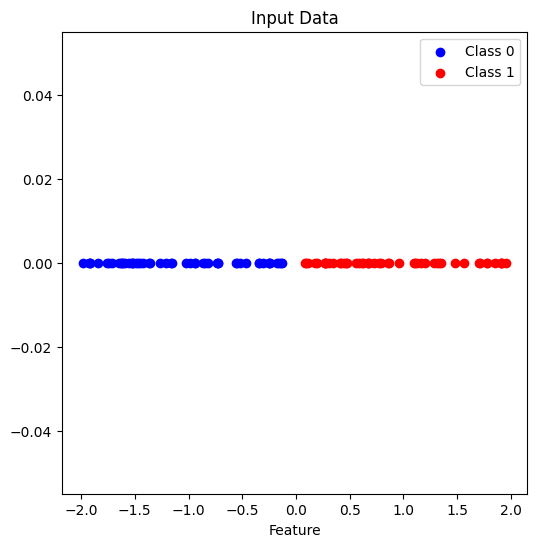

In [9]:
# Generate synthetic data for classification
np.random.seed(0)
X = np.random.uniform(-2, 2, size=(100, 1))  # 100 samples, 1 feature
y = (X >= 0).astype(int)  # Binary classification: 1 if X >= 0, else 0

# Plot the data
plt.figure(figsize=(6, 6))
plt.scatter(X[y==0], np.zeros_like(X[y==0]), color='blue', label='Class 0')
plt.scatter(X[y==1], np.zeros_like(X[y==1]), color='red', label='Class 1')
plt.title('Input Data')
plt.xlabel('Feature')
plt.legend()
plt.show()

## Activation Function

The sigmoid activation function is used to introduce non-linearity into the model.  
Its derivative is used during backpropagation to compute gradients.

In [10]:
# Sigmoid activation function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

First, initialise the parameters. This means determining the following:

**Size of the network**

Hidden layers (or a single hidden layer in this example) can be any size. Layers with more neurons are more powerful, but also more likely to overfit, and take longer to train. The output layer size corresponds to the number of classes.

**Number of iterations**

This parameter determines how many times the network will be updated.

**Learning rate**

Each time we update the weights, we do so by taking a step into the direction that we calculated will improve the accuracy of the network. The size of that step is determined by the learning rate. Taking small steps will slow the process down, but taking steps that are too large can cause results to vary wildly and not reach a stable optimum.

## Model Initialisation

We define the structure of the neural network including:
- Input size
- Hidden layer size
- Output size

Weights are initialised randomly, and training parameters such as the number of iterations and learning rate are set.

In [11]:
# Initialize parameters
input_size = 1        # 1 feature
hidden_size = 4       # you can experiment later
output_size = 1       # binary classification

# Initialize weights
np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size)
W2 = np.random.randn(hidden_size, output_size)

# Training parameters
num_iter = 1000
learning_rate = 0.1

Next, fill in the code below to train a multi-layer perceptron and see if it correctly classifies the input.

## Training the Neural Network

The model is trained using forward propagation and backpropagation.

- Forward pass computes predictions
- Loss is calculated using binary cross-entropy
- Backward pass computes gradients
- Weights are updated using gradient descent

In [12]:
# Training loop
losses = []

for iter in range(num_iter):

    # Forward pass
    Z1 = np.dot(X, W1)
    A1 = sigmoid(Z1)
    Z2 = np.dot(A1, W2)
    y_pred = sigmoid(Z2)

    # Compute loss (binary cross-entropy)
    loss = -np.mean(y * np.log(y_pred + 1e-8) + (1 - y) * np.log(1 - y_pred + 1e-8))
    losses.append(loss)

    # Backward pass
    dZ2 = y_pred - y
    dW2 = np.dot(A1.T, dZ2)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * sigmoid_derivative(Z1)
    dW1 = np.dot(X.T, dZ1)

    # Update weights
    W2 -= learning_rate * dW2
    W1 -= learning_rate * dW1

    # Print loss
    if iter % 100 == 0:
        print(f"Iteration {iter}, Loss: {loss:.4f}")

Iteration 0, Loss: 0.6046
Iteration 100, Loss: 0.0063
Iteration 200, Loss: 0.0030
Iteration 300, Loss: 0.0019
Iteration 400, Loss: 0.0014
Iteration 500, Loss: 0.0010
Iteration 600, Loss: 0.0008
Iteration 700, Loss: 0.0007
Iteration 800, Loss: 0.0006
Iteration 900, Loss: 0.0005


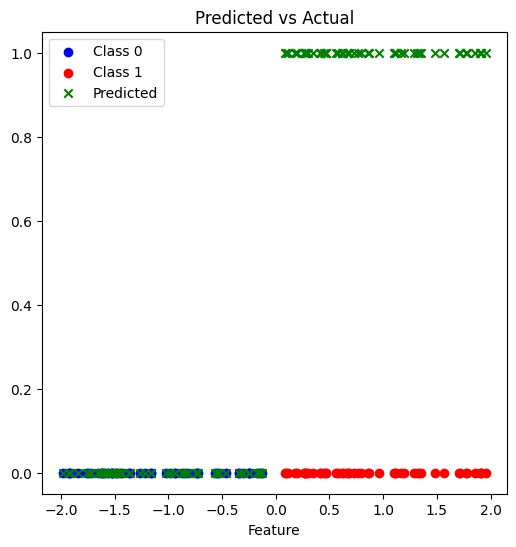

In [13]:
# Plot the decision boundary and predicted classes
plt.figure(figsize=(6, 6))
plt.scatter(X[y==0], np.zeros_like(X[y==0]), color='blue', label='Class 0')
plt.scatter(X[y==1], np.zeros_like(X[y==1]), color='red', label='Class 1')
plt.scatter(X, y_pred >= 0.5, color='green', marker='x', label='Predicted')
plt.title('Predicted vs Actual')
plt.xlabel('Feature')
plt.legend()
plt.show()

We also want to know the impact and interplay of different values for the learning rate and number of iterations.

* What learning rates and numbers of iterations worked well?

* Try varying the size of the hidden layer and experiment with different activation functions (e.g. ReLu).

## Model Evaluation

### Learning Rate and Iterations
A learning rate of 0.1 and 1000 iterations worked well as the model converged and the loss decreased steadily.

### Hidden Layer Size
Increasing the hidden layer size improves model capacity but may lead to overfitting.

### Activation Functions
Sigmoid works well for binary classification, but ReLU could improve training speed and performance in deeper networks.

## Additional Experiments

### Learning Rate and Iterations
I tested a smaller learning rate of 0.01 and observed that the model learned more slowly and required more iterations to converge.  
A learning rate of 0.1 with 1000 iterations resulted in faster and stable convergence.

### Hidden Layer Size
I experimented with different hidden layer sizes. A smaller hidden layer reduced the model’s ability to learn patterns, while increasing the size improved capacity but was not necessary for this simple dataset.

### Activation Functions
I considered using ReLU as an alternative activation function. However, sigmoid performed well for this binary classification task, while ReLU may be more useful in deeper networks.